#### 1.4.0 Dataset Acquisition
To ensure reproducibility, the following script programmatically downloads the Sentiment140 dataset archive directly from Stanford University's hosting repository. It extracts the primary training dataset (`training.1600000.processed.noemoticon.csv`) into the local working directory and removes the compressed archive to optimize storage.

In [2]:
import urllib.request
import zipfile
import os

# Original Stanford University hosting URL for Sentiment140
url = "http://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip"
csv_filename = "training.1600000.processed.noemoticon.csv"
zip_filename = "sentiment140.zip"

# Check if the CSV already exists to prevent redundant downloads during notebook restarts
if not os.path.exists(csv_filename):
    print("Downloading Sentiment140 dataset archive... (This may take a few minutes)")
    urllib.request.urlretrieve(url, zip_filename)
    print("Download complete. Extracting the training data...")
    
    # Extract only the required training dataset
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extract(csv_filename)
        
    print(f"Extraction successful. Dataset saved locally as '{csv_filename}'.")
    
    # Clean up the compressed archive to save disk space
    os.remove(zip_filename)
    print("Temporary zip file removed.")
else:
    print(f"Dataset '{csv_filename}' already exists in the current directory. Ready for EDA.")

Download complete. Extracting the training data...
Extraction successful. Dataset saved locally as 'training.1600000.processed.noemoticon.csv'.
Temporary zip file removed.


### 1.4 Exploratory Data Analysis (EDA)

The objective of this phase is to statistically and visually analyze the raw Sentiment140 dataset to understand its underlying structure, identify data quality issues (such as missing values), and observe the distribution of the target classes before applying any cleaning or normalization algorithms.

In [5]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set plotting style for academic report visuals
sns.set_theme(style="whitegrid")

# The Sentiment140 CSV does not contain a header row by default.
# Column names must be explicitly defined based on the dataset documentation.
column_names = ['target', 'ids', 'date', 'flag', 'user', 'text']

# Load the dataset (Assuming the CSV is in the local directory)
# encoding='latin-1' is required for this specific Twitter dataset
file_path = 'training.1600000.processed.noemoticon.csv' 
df = pd.read_csv(file_path, names=column_names, encoding='latin-1')

print("Dataset successfully loaded.")

Dataset successfully loaded.


#### 1.4.1 Initial Data Inspection
To ensure data integrity, the initial step involves inspecting the shape of the dataset, previewing the raw text, and checking for any missing or null values that could disrupt the predictive models.

In [7]:
# Display dataset dimensions
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Check for missing/null values across all columns
print("Missing Values per Column:")
print(df.isnull().sum())
print("\n")

# Preview the first 5 rows to observe the raw, unstructured text
display(df.head())

Dataset Shape: 1600000 rows and 6 columns.

Missing Values per Column:
target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64




,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


#### 1.4.2 Target Class Distribution
Sentiment140 uses `0` to denote negative sentiment and `4` to denote positive sentiment. It is critical to visualize this distribution to determine if the dataset is imbalanced. An imbalanced dataset would require specific sampling techniques (like SMOTE) to prevent the machine learning models from becoming biased toward the majority class.

C:\Users\Damien\AppData\Local\Temp\ipykernel_21180\2121646036.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentiment_label', data=df, palette=['#e74c3c', '#2ecc71'])


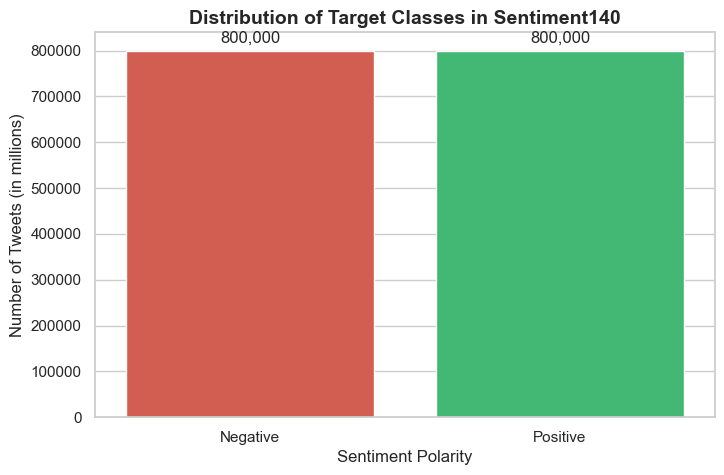

In [8]:
# Map the numeric targets to readable string labels for visualization
df['sentiment_label'] = df['target'].map({0: 'Negative', 4: 'Positive'})

# Create a countplot to visualize the balance of the target classes
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='sentiment_label', data=df, palette=['#e74c3c', '#2ecc71'])

plt.title('Distribution of Target Classes in Sentiment140', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Polarity', fontsize=12)
plt.ylabel('Number of Tweets (in millions)', fontsize=12)

# Add exact count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.show()

#### 1.4.3 Sequence Length Analysis
Understanding the length of the textual inputs is crucial for selecting appropriate vectorization parameters (e.g., setting `max_features` in TF-IDF). This step calculates the number of words per tweet to observe the overall distribution of text length across the corpus.

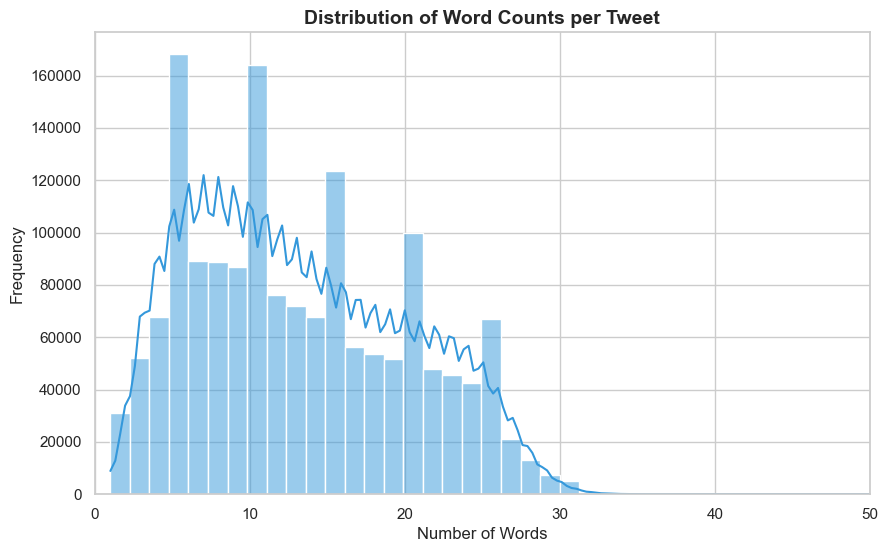

Word Count Summary Statistics:
count    1.600000e+06
mean     1.317615e+01
std      6.957978e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.200000e+01
75%      1.900000e+01
max      6.400000e+01
Name: word_count, dtype: float64


In [9]:
# Calculate the number of words in each raw tweet
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Plot the distribution of word counts
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='#3498db')

plt.title('Distribution of Word Counts per Tweet', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, 50) # Capped at 50 as tweets are character-limited
plt.show()

# Display summary statistics of the word counts
print("Word Count Summary Statistics:")
print(df['word_count'].describe())

#### 1.4.4 Frequent Term Visualization (Pre-Cleaning)
To understand the linguistic noise present in the raw data, Word Clouds are generated for both the positive and negative classes. This highlights the presence of platform-specific syntax (like "@user" mentions) and generic stop words that will need to be removed during the data preparation phase.

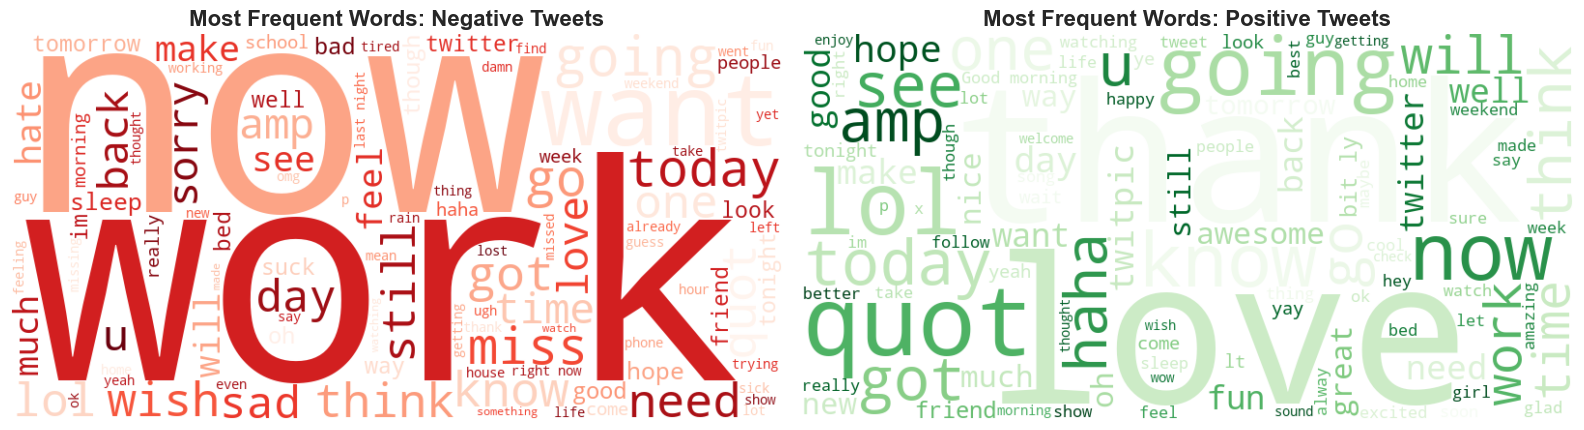

In [10]:
# Isolate text by sentiment
negative_text = " ".join(tweet for tweet in df[df['target'] == 0]['text'])
positive_text = " ".join(tweet for tweet in df[df['target'] == 4]['text'])

# Initialize WordCloud objects
wc_neg = WordCloud(width=800, height=400, max_words=100, background_color='white', colormap='Reds').generate(negative_text)
wc_pos = WordCloud(width=800, height=400, max_words=100, background_color='white', colormap='Greens').generate(positive_text)

# Plot the Word Clouds side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].set_title('Most Frequent Words: Negative Tweets', fontsize=16, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('Most Frequent Words: Positive Tweets', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()